# Notebook 4: Perturbation Response

This notebook first checks whether the perturbations show evidence of an on-target transcriptional effect, then defines a simple per-cell measure of expression change relative to a control group for use in Notebook 5.

`62(mod)_pBA581` is used as the working negative control based on the available dataset and literature evidence. However, its identity is not directly confirmed by a primary-source statement naming this exact guide, so it is treated as an explicit assumption rather than an established fact.

The control assignment and response definition established here will be used in the downstream heterogeneity analysis.


## Setup

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Loading the preprocessed dataset

In [3]:
data_path = "F:/scRNA/adamson_pilot_preprocessed.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5752 × 14690
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mean_log_expression', 'variance_log_expression', 'dispersion', 'highly_variable'
    obsm: 'X_pca'
    layers: 'counts'

In [4]:
control_label = "62(mod)_pBA581"
is_control = adata.obs["perturbation"] == control_label
print("control cells:", is_control.sum())

control cells: 1769


## Sanity check: did the guides knock down their own target genes?


In [5]:
target_labels = [c for c in adata.obs["perturbation"].cat.categories if c != control_label]
target_genes = {label: label.split("_")[0] for label in target_labels}

for label, gene in target_genes.items():
    found = gene in adata.var_names
    print(f"{label} -> target gene {gene}, present in dataset: {found}")

BHLHE40_pDS258 -> target gene BHLHE40, present in dataset: True
CREB1_pDS269 -> target gene CREB1, present in dataset: True
DDIT3_pDS263 -> target gene DDIT3, present in dataset: True
EP300_pDS268 -> target gene EP300, present in dataset: True
SNAI1_pDS266 -> target gene SNAI1, present in dataset: True
SPI1_pDS255 -> target gene SPI1, present in dataset: True
ZNF326_pDS262 -> target gene ZNF326, present in dataset: True


In [6]:
X_all = adata.X.tocsc()

rows = []
for label, gene in target_genes.items():
    if gene not in adata.var_names:
        continue
    gene_col = adata.var_names.get_loc(gene)
    gene_expr = np.asarray(X_all[:, gene_col].todense()).flatten()

    mask_target = (adata.obs["perturbation"] == label).values
    mean_in_target = gene_expr[mask_target].mean()
    mean_in_control = gene_expr[is_control.values].mean()
    rows.append({
        "perturbation": label,
        "target_gene": gene,
        "mean_expression_in_target_cells": mean_in_target,
        "mean_expression_in_control_cells": mean_in_control,
        "ratio": mean_in_target / mean_in_control if mean_in_control > 0 else np.nan,
    })

on_target_summary = pd.DataFrame(rows).sort_values("ratio")
on_target_summary

,perturbation,target_gene,mean_expression_in_target_cells,mean_expression_in_control_cells,ratio
4,SNAI1_pDS266,SNAI1,0.000000,0.031294,0.000000
5,SPI1_pDS255,SPI1,0.012362,0.209718,0.058946
6,ZNF326_pDS262,ZNF326,0.069785,0.385148,0.181191
2,DDIT3_pDS263,DDIT3,0.034814,0.189770,0.183456
0,BHLHE40_pDS258,BHLHE40,0.040940,0.221112,0.185157
1,CREB1_pDS269,CREB1,0.031408,0.101231,0.310267
3,EP300_pDS268,EP300,0.023615,0.036676,0.643878


## Defining "response"


In [7]:
hvg_mask = adata.var["highly_variable"]
X_hvg = adata[:, hvg_mask].X
X_hvg = np.asarray(X_hvg.todense()) if sp.issparse(X_hvg) else np.asarray(X_hvg)
print("expression matrix used for response vectors:", X_hvg.shape)

expression matrix used for response vectors: (5752, 2000)


In [8]:
control_centroid = X_hvg[is_control.values].mean(axis=0)

In [9]:
response_vectors = X_hvg - control_centroid
response_magnitude = np.linalg.norm(response_vectors, axis=1)

adata.obs["response_magnitude"] = response_magnitude
adata.obs[["perturbation", "response_magnitude"]].groupby("perturbation", observed=True).describe()

response_magnitude                                          \
                            count      mean       std       min       25%   
perturbation                                                                
62(mod)_pBA581             1769.0  5.952292  1.154598  3.812984  5.269959   
BHLHE40_pDS258              553.0  6.002255  1.191424  4.002738  5.323768   
CREB1_pDS269                506.0  5.907306  1.087581  4.071232  5.263857   
DDIT3_pDS263                477.0  5.875082  1.013949  4.025353  5.196976   
EP300_pDS268                632.0  5.849606  0.977123  3.485215  5.269922   
SNAI1_pDS266                562.0  6.112988  1.117418  4.443662  5.446264   
SPI1_pDS255                 696.0  6.317997  1.373121  4.063695  5.511358   
ZNF326_pDS262               557.0  5.776765  1.040754  3.940226  5.126827   

                                               
                     50%       75%        max  
perturbation                                   
62(mod)_pBA581  5.762155  6.350143  17.302391  
BHLHE40_pDS258  5.782660  6.423715  19.166082  
CREB1_pDS269    5.693789  6.251697  13.196651  
DDIT3_pDS263    5.669438  6.387281  12.331072  
EP300_pDS268    5.679216  6.197830  13.300871  
SNAI1_pDS266    5.886878  6.457836  14.776804  
SPI1_pDS255     6.065490  6.724293  19.418606  
ZNF326_pDS262   5.588712  6.195387  13.722230

## Response magnitude by perturbation

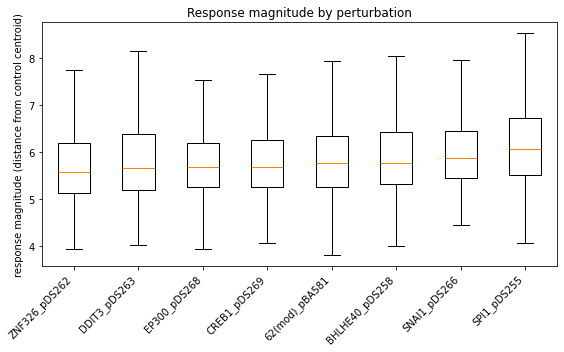

In [10]:
categories = adata.obs["perturbation"].cat.categories
data_by_group = [adata.obs.loc[adata.obs["perturbation"] == cat, "response_magnitude"].values
                 for cat in categories]

order = np.argsort([np.median(d) for d in data_by_group])

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([data_by_group[i] for i in order],
           tick_labels=[str(categories[i]) for i in order],
           showfliers=False)
ax.set_ylabel("response magnitude (distance from control centroid)")
ax.set_title("Response magnitude by perturbation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Saving



In [11]:
output_path = "F:/scRNA/adamson_pilot_with_response.h5ad"
adata.write(output_path)
print("saved to", output_path)

saved to F:/scRNA/adamson_pilot_with_response.h5ad
